In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Python environment is ready!")

Python environment is ready!


In [2]:
df = pd.read_csv("Hospital_Operations_Patient_Analytics_Cleaned_Data.csv")

df.head()

,Record_ID,Patient_ID,Admission_Date,Discharge_Date,Patient_Name,Age,Gender,City,State,Department,...,Room_Type,Length_of_Stay_Days,Wait_Time_Minutes,Payment_Mode,Total_Bill,Insurance_Coverage,Patient_Paid,Satisfaction_Rating,Readmission,Discharge_Status
0,REC101977,P101977,01-01-2024,05-01-2024,Patient_00001,77,Male,Delhi,Delhi,Cardiology,...,Semi-Private,4,5,Debit Card,68923.90,0.00,68923.90,5.0,No,Recovered
1,REC122813,P122813,01-01-2024,03-01-2024,Patient_00002,79,Male,Gaya,Bihar,ENT,...,ICU,2,41,Insurance,27945.48,25574.04,2371.44,4.2,No,Recovered
2,REC106623,P106623,01-01-2024,07-01-2024,Patient_00003,86,Female,Kolkata,West Bengal,Gynecology,...,Private,6,5,Cash,39629.58,0.00,39629.58,4.3,Yes,Discharged
3,REC100648,P100648,01-01-2024,07-01-2024,Patient_00004,84,Male,Varanasi,Uttar Pradesh,Cardiology,...,General Ward,6,42,Credit Card,79167.45,0.00,79167.45,4.9,No,Recovered
4,REC120266,P120266,01-01-2024,03-01-2024,Patient_00005,77,Male,Gaya,Bihar,Dermatology,...,General Ward,2,36,Debit Card,16414.41,0.00,16414.41,4.8,Yes,Discharged


In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 30000
Columns: 24


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Record_ID            30000 non-null  str    
 1   Patient_ID           30000 non-null  str    
 2   Admission_Date       30000 non-null  str    
 3   Discharge_Date       30000 non-null  str    
 4   Patient_Name         30000 non-null  str    
 5   Age                  30000 non-null  int64  
 6   Gender               30000 non-null  str    
 7   City                 30000 non-null  str    
 8   State                30000 non-null  str    
 9   Department           30000 non-null  str    
 10  Condition            30000 non-null  str    
 11  Admission_Type       30000 non-null  str    
 12  Patient_Type         30000 non-null  str    
 13  Doctor_ID            30000 non-null  str    
 14  Room_Type            30000 non-null  str    
 15  Length_of_Stay_Days  30000 non-null  int64  
 1

In [5]:
df.describe()

,Age,Length_of_Stay_Days,Wait_Time_Minutes,Total_Bill,Insurance_Coverage,Patient_Paid,Satisfaction_Rating
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.00000
mean,53.205233,4.094433,39.315633,45226.918215,14182.564185,30990.292357,4.49016
std,24.785054,2.506842,18.832253,19603.508056,19600.418684,22718.027554,0.48578
min,1.000000,1.000000,5.000000,10443.100000,0.000000,709.410000,1.80000
25%,34.000000,2.000000,26.000000,30038.852500,0.000000,11591.255000,4.20000
50%,56.000000,4.000000,39.000000,41720.740000,0.000000,26693.830000,4.60000
75%,75.000000,5.000000,53.000000,57505.952500,27347.612500,45507.017500,5.00000
max,90.000000,20.000000,110.000000,344231.280000,116446.110000,162879.170000,5.00000


In [7]:
df["Admission_Date"] = pd.to_datetime(
    df["Admission_Date"],
    format="%d-%m-%Y"
)

df["Discharge_Date"] = pd.to_datetime(
    df["Discharge_Date"],
    format="%d-%m-%Y"
)

In [8]:
df[["Admission_Date", "Discharge_Date"]].dtypes

Admission_Date    datetime64[us]
Discharge_Date    datetime64[us]
dtype: object

In [10]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

Series([], dtype: int64)

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df["Record_ID"].nunique()

30000

In [13]:
df["Gender"].value_counts()

Gender
Male      15295
Female    14358
Other       307
male         20
female       20
Name: count, dtype: int64

In [14]:
df["Gender"] = df["Gender"].str.strip().str.title()

In [15]:
df["Gender"].value_counts()

Gender
Male      15315
Female    14378
Other       307
Name: count, dtype: int64

In [65]:
numeric_columns = [
    "Age",
    "Length_of_Stay_Days",
    "Wait_Time_Minutes",
    "Total_Bill",
    "Insurance_Coverage",
    "Patient_Paid",
    "Satisfaction_Rating"
]

outlier_summary = []

for column in numeric_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    outlier_summary.append({
        "Column": column,
        "Q1": Q1,
        "Q3": Q3,
        "Lower_Bound": lower_bound,
        "Upper_Bound": upper_bound,
        "Outlier_Count": len(outliers)
    })

outlier_df = pd.DataFrame(outlier_summary)

outlier_df

,Column,Q1,Q3,Lower_Bound,Upper_Bound,Outlier_Count
0,Age,34.0000,75.0000,-27.50000,136.50000,0
1,Length_of_Stay_Days,2.0000,5.0000,-2.50000,9.50000,1078
2,Wait_Time_Minutes,26.0000,53.0000,-14.50000,93.50000,71
3,Total_Bill,30038.8525,57505.9525,-11161.79750,98706.60250,302
4,Insurance_Coverage,0.0000,27347.6125,-41021.41875,68369.03125,431
5,Patient_Paid,11591.2550,45507.0175,-39282.38875,96380.66125,199
6,Satisfaction_Rating,4.2000,5.0000,3.00000,6.20000,187


In [29]:
df.nlargest(10, "Total_Bill")[
    ["Record_ID", "Department", "Condition", "Length_of_Stay_Days", "Total_Bill"]
]

,Record_ID,Department,Condition,Length_of_Stay_Days,Total_Bill
6715,REC104364,Cardiology,Hypertension,4,344231.28
9068,REC116325,Cardiology,Arrhythmia,2,295051.32
26660,REC128450,Orthopedics,Fracture,6,284525.92
16845,REC107466,Orthopedics,Back Pain,3,233689.16
11321,REC126240,Orthopedics,Arthritis,2,183643.92
29600,REC113427,Gynecology,Anemia,2,181884.20
4612,REC111523,Cardiology,Hypertension,20,162879.17
27322,REC102583,Cardiology,Arrhythmia,16,159481.31
5353,REC107064,Cardiology,Arrhythmia,17,159016.45
2870,REC109590,Cardiology,Chest Pain,20,158520.79


In [32]:
age_bins = [0, 18, 35, 50, 65, 100]
age_labels = [
    "0-18",
    "19-35",
    "36-50",
    "51-65",
    "66+"
]

df["Age_Group"] = pd.cut(
    df["Age"],
    bins=age_bins,
    labels=age_labels,
    include_lowest=True
)

df["Age_Group"].value_counts().sort_index()

Age_Group
0-18      3527
19-35     4421
36-50     4953
51-65     5675
66+      11424
Name: count, dtype: int64

In [33]:
monthly_admissions = (
    df.groupby(df["Admission_Date"].dt.to_period("M"))
      .size()
      .reset_index(name="Admissions")
)

monthly_admissions["Admission_Date"] = monthly_admissions["Admission_Date"].dt.to_timestamp()

monthly_admissions

,Admission_Date,Admissions
0,2024-01-01,1291
1,2024-02-01,1162
2,2024-03-01,1296
3,2024-04-01,1252
4,2024-05-01,1254
5,2024-06-01,1210
6,2024-07-01,1222
7,2024-08-01,1293
8,2024-09-01,1255
9,2024-10-01,1250


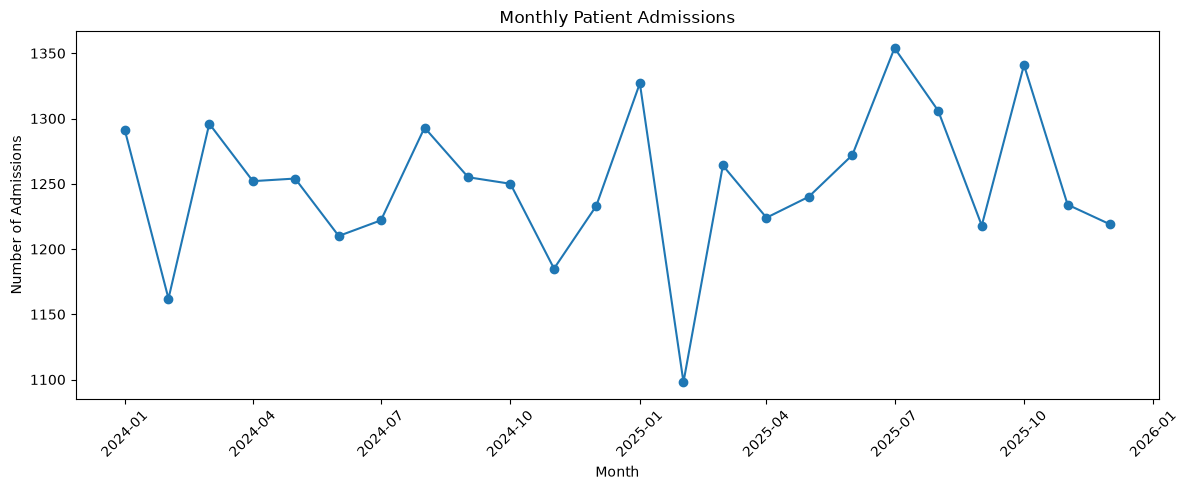

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_admissions["Admission_Date"],
    monthly_admissions["Admissions"],
    marker="o"
)

plt.title("Monthly Patient Admissions")
plt.xlabel("Month")
plt.ylabel("Number of Admissions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [35]:
department_volume = (
    df["Department"]
    .value_counts()
    .reset_index()
)

department_volume.columns = ["Department", "Patient_Records"]

department_volume

,Department,Patient_Records
0,General Medicine,5364
1,Pediatrics,3929
2,Orthopedics,3618
3,Gynecology,3574
4,Cardiology,3339
5,Emergency,3310
6,Neurology,2483
7,Dermatology,2309
8,ENT,2074


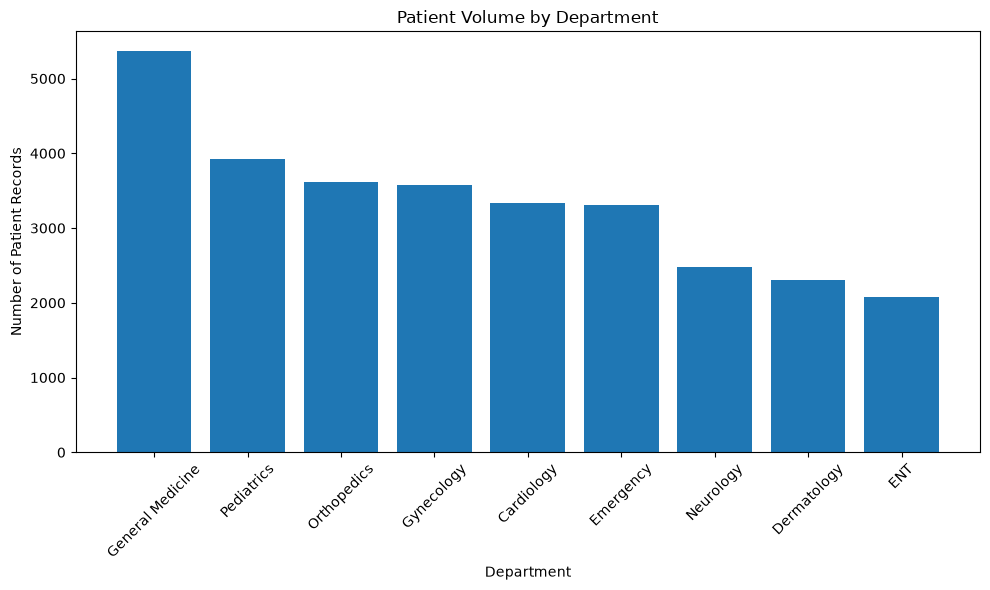

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    department_volume["Department"],
    department_volume["Patient_Records"]
)

plt.title("Patient Volume by Department")
plt.xlabel("Department")
plt.ylabel("Number of Patient Records")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [37]:
department_avg_bill = (
    df.groupby("Department")["Total_Bill"]
      .mean()
      .round(2)
      .reset_index()
)

department_avg_bill = department_avg_bill.sort_values(
    "Total_Bill",
    ascending=False
)

department_avg_bill

,Department,Total_Bill
0,Cardiology,73942.90
6,Neurology,67461.19
7,Orthopedics,55737.33
3,Emergency,47552.53
5,Gynecology,42706.61
4,General Medicine,34957.93
8,Pediatrics,31983.74
2,ENT,28483.31
1,Dermatology,25319.74


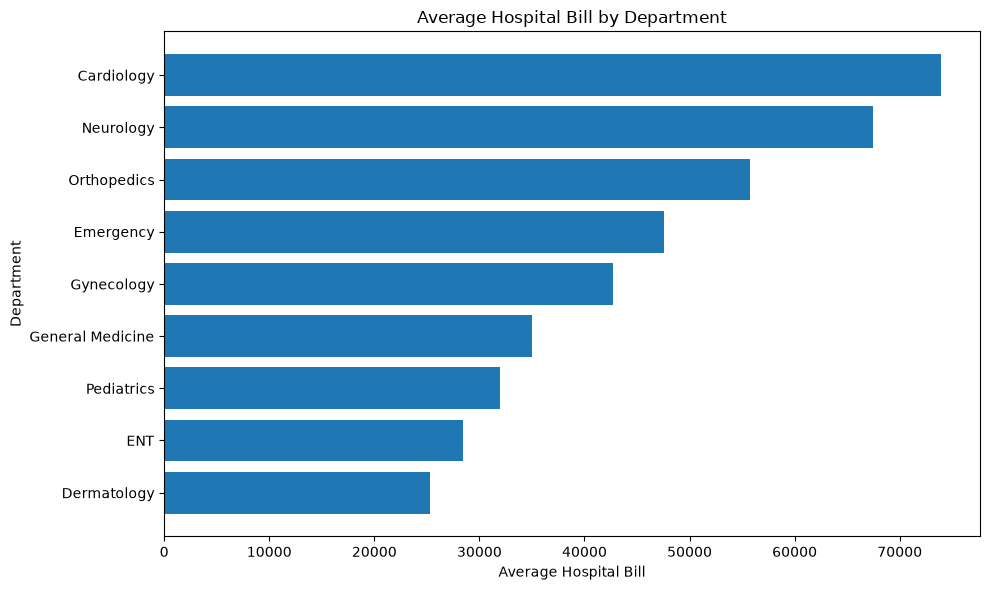

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.barh(
    department_avg_bill["Department"],
    department_avg_bill["Total_Bill"]
)

plt.title("Average Hospital Bill by Department")
plt.xlabel("Average Hospital Bill")
plt.ylabel("Department")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [51]:
satisfaction_summary = pd.DataFrame({
    "Metric": [
        "Average Satisfaction Rating",
        "Minimum Rating",
        "Maximum Rating"
    ],
    "Value": [
        df["Satisfaction_Rating"].mean(),
        df["Satisfaction_Rating"].min(),
        df["Satisfaction_Rating"].max()
    ]
})

satisfaction_summary["Value"] = satisfaction_summary["Value"].round(2)

satisfaction_summary

,Metric,Value
0,Average Satisfaction Rating,4.49
1,Minimum Rating,1.80
2,Maximum Rating,5.00


In [52]:
satisfaction_distribution = (
    df["Satisfaction_Rating"]
    .round(1)
    .value_counts()
    .sort_index()
    .reset_index()
)

satisfaction_distribution.columns = [
    "Satisfaction_Rating",
    "Patient_Records"
]

satisfaction_distribution

,Satisfaction_Rating,Patient_Records
0,1.8,1
1,2.0,1
2,2.1,1
3,2.3,1
4,2.4,3
5,2.5,5
6,2.6,10
7,2.7,18
8,2.8,33
9,2.9,46


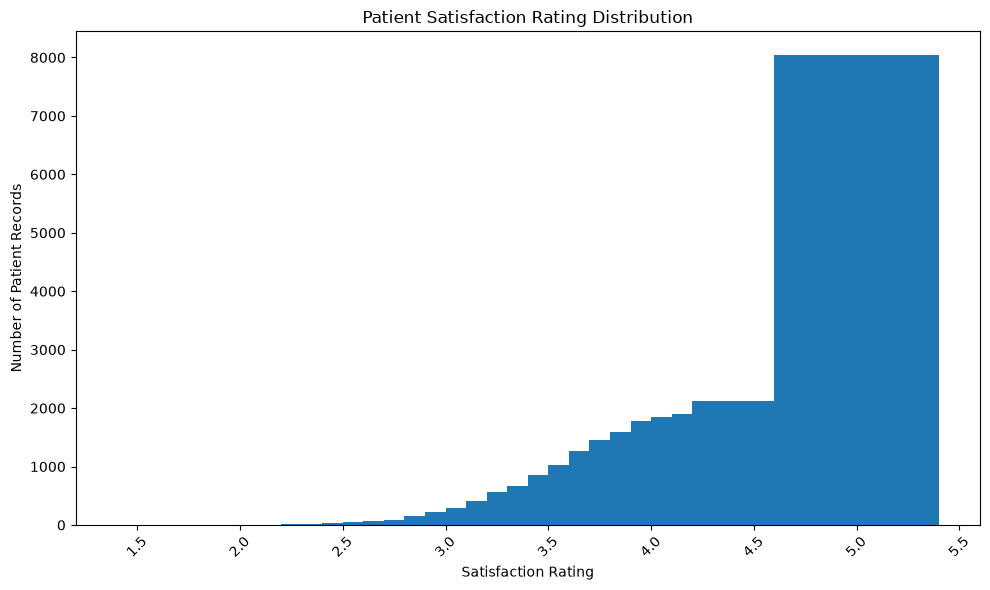

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    satisfaction_distribution["Satisfaction_Rating"],
    satisfaction_distribution["Patient_Records"]
)

plt.title("Patient Satisfaction Rating Distribution")
plt.xlabel("Satisfaction Rating")
plt.ylabel("Number of Patient Records")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [54]:
wait_satisfaction_corr = df[
    ["Wait_Time_Minutes", "Satisfaction_Rating"]
].corr()

wait_satisfaction_corr

,Wait_Time_Minutes,Satisfaction_Rating
Wait_Time_Minutes,1.000000,-0.390837
Satisfaction_Rating,-0.390837,1.000000


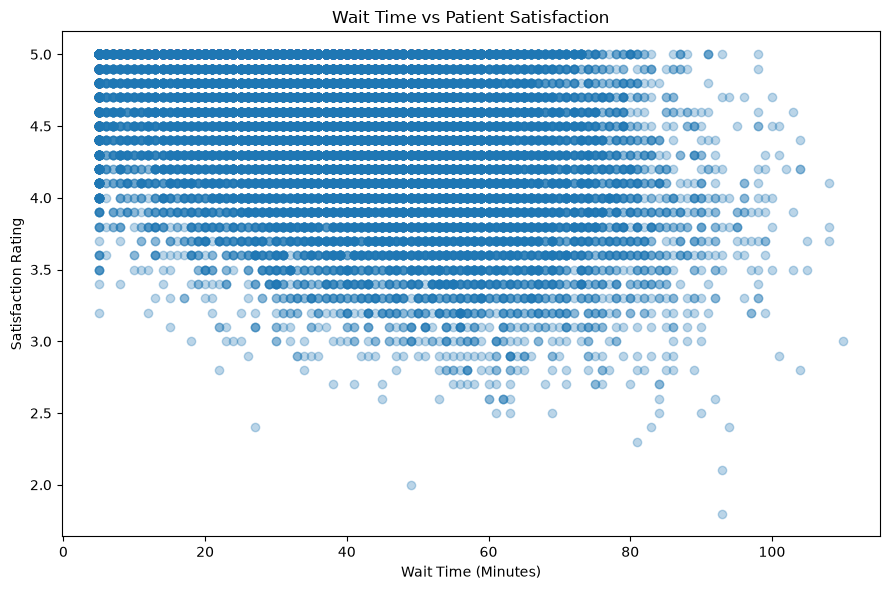

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

plt.scatter(
    df["Wait_Time_Minutes"],
    df["Satisfaction_Rating"],
    alpha=0.3
)

plt.title("Wait Time vs Patient Satisfaction")
plt.xlabel("Wait Time (Minutes)")
plt.ylabel("Satisfaction Rating")

plt.tight_layout()
plt.show()

In [56]:
los_summary = pd.DataFrame({
    "Metric": [
        "Average Length of Stay",
        "Minimum Length of Stay",
        "Maximum Length of Stay"
    ],
    "Value": [
        df["Length_of_Stay_Days"].mean(),
        df["Length_of_Stay_Days"].min(),
        df["Length_of_Stay_Days"].max()
    ]
})

los_summary["Value"] = los_summary["Value"].round(2)

los_summary

,Metric,Value
0,Average Length of Stay,4.09
1,Minimum Length of Stay,1.00
2,Maximum Length of Stay,20.00


In [57]:
los_distribution = (
    df["Length_of_Stay_Days"]
    .value_counts()
    .sort_index()
    .reset_index()
)

los_distribution.columns = [
    "Length_of_Stay_Days",
    "Patient_Records"
]

los_distribution

,Length_of_Stay_Days,Patient_Records
0,1,3744
1,2,5153
2,3,5453
3,4,4817
4,5,3722
5,6,2594
6,7,1681
7,8,1068
8,9,690
9,10,400


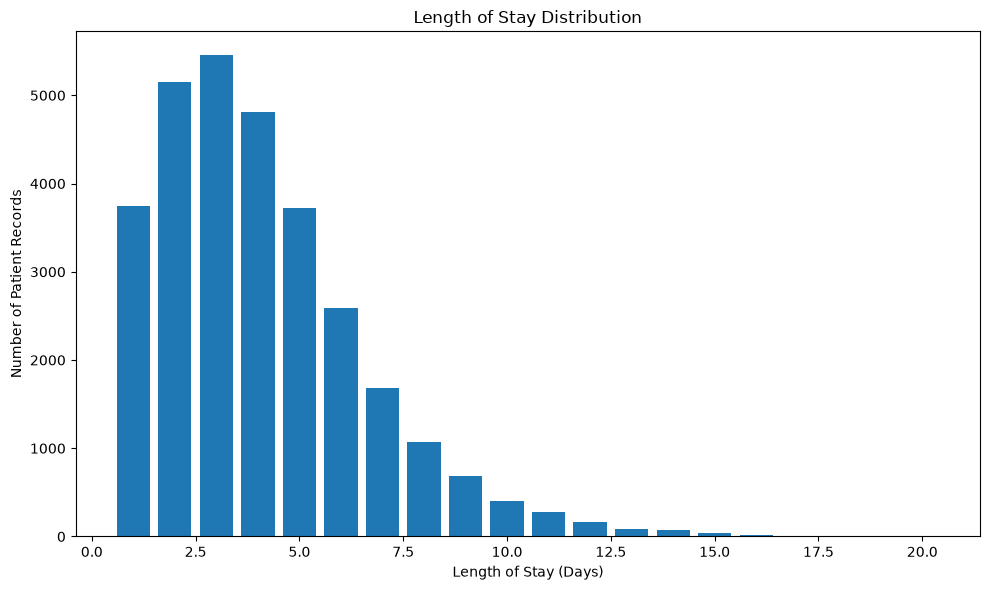

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    los_distribution["Length_of_Stay_Days"],
    los_distribution["Patient_Records"]
)

plt.title("Length of Stay Distribution")
plt.xlabel("Length of Stay (Days)")
plt.ylabel("Number of Patient Records")

plt.tight_layout()
plt.show()

In [59]:
los_bill_corr = df[
    ["Length_of_Stay_Days", "Total_Bill"]
].corr()

los_bill_corr

,Length_of_Stay_Days,Total_Bill
Length_of_Stay_Days,1.000000,0.550214
Total_Bill,0.550214,1.000000


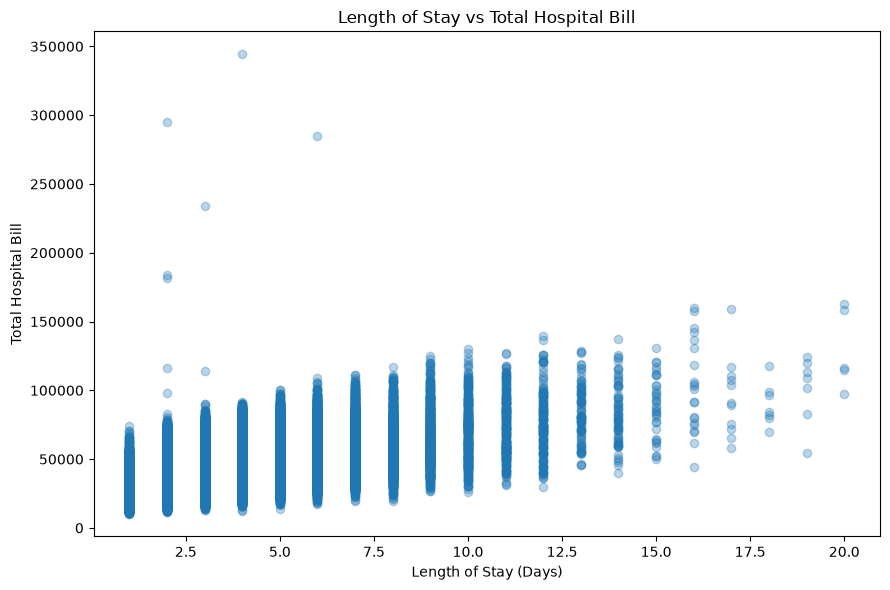

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

plt.scatter(
    df["Length_of_Stay_Days"],
    df["Total_Bill"],
    alpha=0.3
)

plt.title("Length of Stay vs Total Hospital Bill")
plt.xlabel("Length of Stay (Days)")
plt.ylabel("Total Hospital Bill")

plt.tight_layout()
plt.show()

In [61]:
department_analysis = (
    df.groupby("Department")
    .agg(
        Patient_Records=("Record_ID", "count"),
        Average_Bill=("Total_Bill", "mean"),
        Average_Length_of_Stay=("Length_of_Stay_Days", "mean")
    )
    .reset_index()
)

department_analysis["Average_Bill"] = department_analysis["Average_Bill"].round(2)
department_analysis["Average_Length_of_Stay"] = (
    department_analysis["Average_Length_of_Stay"].round(2)
)

department_analysis = department_analysis.sort_values(
    "Patient_Records",
    ascending=False
)

department_analysis

,Department,Patient_Records,Average_Bill,Average_Length_of_Stay
4,General Medicine,5364,34957.93,3.92
8,Pediatrics,3929,31983.74,3.95
7,Orthopedics,3618,55737.33,3.91
5,Gynecology,3574,42706.61,3.80
0,Cardiology,3339,73942.90,5.12
3,Emergency,3310,47552.53,3.88
6,Neurology,2483,67461.19,4.72
1,Dermatology,2309,25319.74,3.85
2,ENT,2074,28483.31,3.86


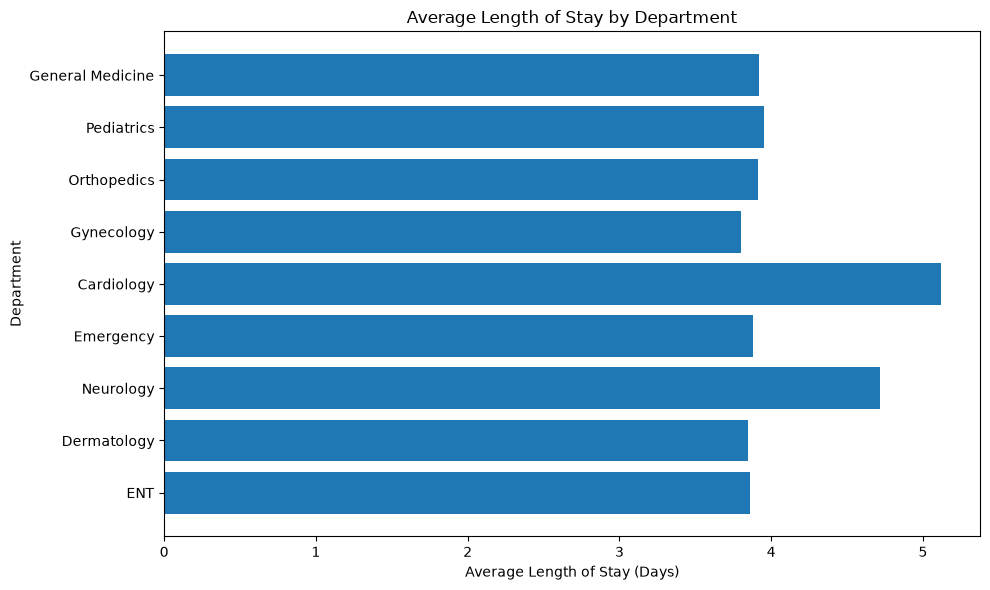

In [62]:
plt.figure(figsize=(10, 6))

plt.barh(
    department_analysis["Department"],
    department_analysis["Average_Length_of_Stay"]
)

plt.title("Average Length of Stay by Department")
plt.xlabel("Average Length of Stay (Days)")
plt.ylabel("Department")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()